# Команда 12. Смирнова М., Дворяшина И., Шумакова В., Шилкова А.

# Импорты библиотек

In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Чтение данных

In [83]:
df_path = "videostreaming_platform.csv"

df = pd.read_csv(df_path)

df.head()

,user_id,start_trial_date,city,device,source,favourite_genre,avg_min_watch_daily,number_of_days_logged,churn
0,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-01,St Petersburg,ios,performance,drama,2.076642,4,1
1,f1bf2396-73d8-461e-a775-9f068bd99326,2024-02-01,Other,web,seo,criminal,5.101392,1,1
2,ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28,2024-02-01,Ufa,web,performance,criminal,2.906597,1,1
3,b0195e96-af2e-4ac3-8f60-26b8d862af84,2024-02-01,Moscow,smarttv,seo,thriller,2.702388,6,0
4,a208985a-7244-4291-8d38-64c8141e27b2,2024-02-01,Ufa,web,performance,thriller,10.237305,1,1


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [85]:
# Проверка наличия пустых значений
print("Пропуски в данных: \n", df.isna().sum())

Пропуски в данных: 
 user_id                     0
start_trial_date            0
city                      308
device                      0
source                      0
favourite_genre          7952
avg_min_watch_daily         0
number_of_days_logged       0
churn                       0
dtype: int64


## Пропуски в данных обнаружены у признака 'city' (308) и 'favourite_genre' (7952)

In [86]:
df.describe()

,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


In [87]:
df.describe(include = 'object')

,user_id,start_trial_date,city,device,source,favourite_genre
count,28000,28000,27692,28000,28000,20048
unique,28000,28,9,4,3,5
top,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-28,Moscow,web,performance,drama
freq,1,1103,8736,17752,14540,4928


In [88]:
print("Уникальные значения категориального признака city: ", df['city'].unique())
print("Уникальные значения категориального признака device: ", df['device'].unique())
print("Уникальные значения категориального признака source: ", df['source'].unique())
print("Уникальные значения категориального признака favourite_genre: ", df['favourite_genre'].unique())

Уникальные значения категориального признака city:  ['St Petersburg' 'Other' 'Ufa' 'Moscow' 'Samara' 'Krasnodar'
 'Yekaterinburg' 'Novosibirsk' 'Voronezh' nan]
Уникальные значения категориального признака device:  ['ios' 'web' 'smarttv' 'android']
Уникальные значения категориального признака source:  ['performance' 'seo' 'organic']
Уникальные значения категориального признака favourite_genre:  ['drama' 'criminal' 'thriller' 'comedy' nan 'action']


# Чистка данных

In [89]:
# Преобразование дат в datetime
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

# Замена NaN на "Unknown"
df['city'] = df['city'].fillna('Unknown')
df['favourite_genre'] = df['favourite_genre'].fillna('Unknown')

# Feature Engineering
# Создание новой колонки день недели начала триала
df['trial_start_day_of_week'] = df['start_trial_date'].dt.dayofweek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  28000 non-null  object        
 1   start_trial_date         28000 non-null  datetime64[ns]
 2   city                     28000 non-null  object        
 3   device                   28000 non-null  object        
 4   source                   28000 non-null  object        
 5   favourite_genre          28000 non-null  object        
 6   avg_min_watch_daily      28000 non-null  float64       
 7   number_of_days_logged    28000 non-null  int64         
 8   churn                    28000 non-null  int64         
 9   trial_start_day_of_week  28000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(5)
memory usage: 2.0+ MB


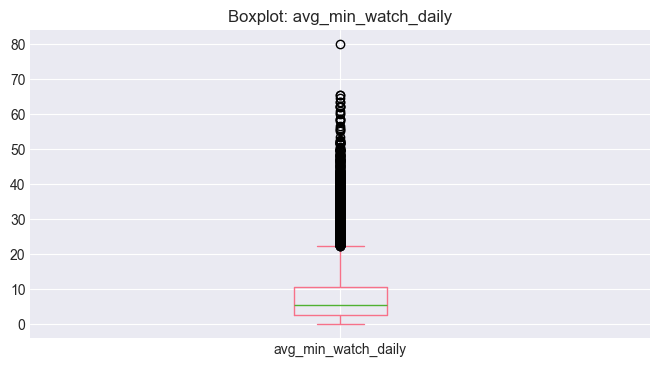

In [90]:
# Построение боксплота распределения и аномалии в данных о среднем времени просмотра
plt.figure(figsize=(8, 4))
df["avg_min_watch_daily"].plot(kind="box")
plt.title("Boxplot: avg_min_watch_daily")
plt.show()

In [91]:
# Расчет процентилей
percentiles = df['avg_min_watch_daily'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Процентили времени просмотра:")
print(percentiles)

Процентили времени просмотра:
0.500     5.419012
0.750    10.487946
0.900    18.095907
0.950    23.691268
0.990    36.007353
0.999    51.902463
Name: avg_min_watch_daily, dtype: float64


Поскольку 80 минут (максимальное значение) - адекватное время просмотра, и в целом для стриминга возможно скошенное распределение, принято решение не проводить очистку от выбросов и работать с исходными данными, чтобы не потерять полезную информацию для анализа конверсии

# Построение диаграмм категориальных признаков для анализа распределение данных

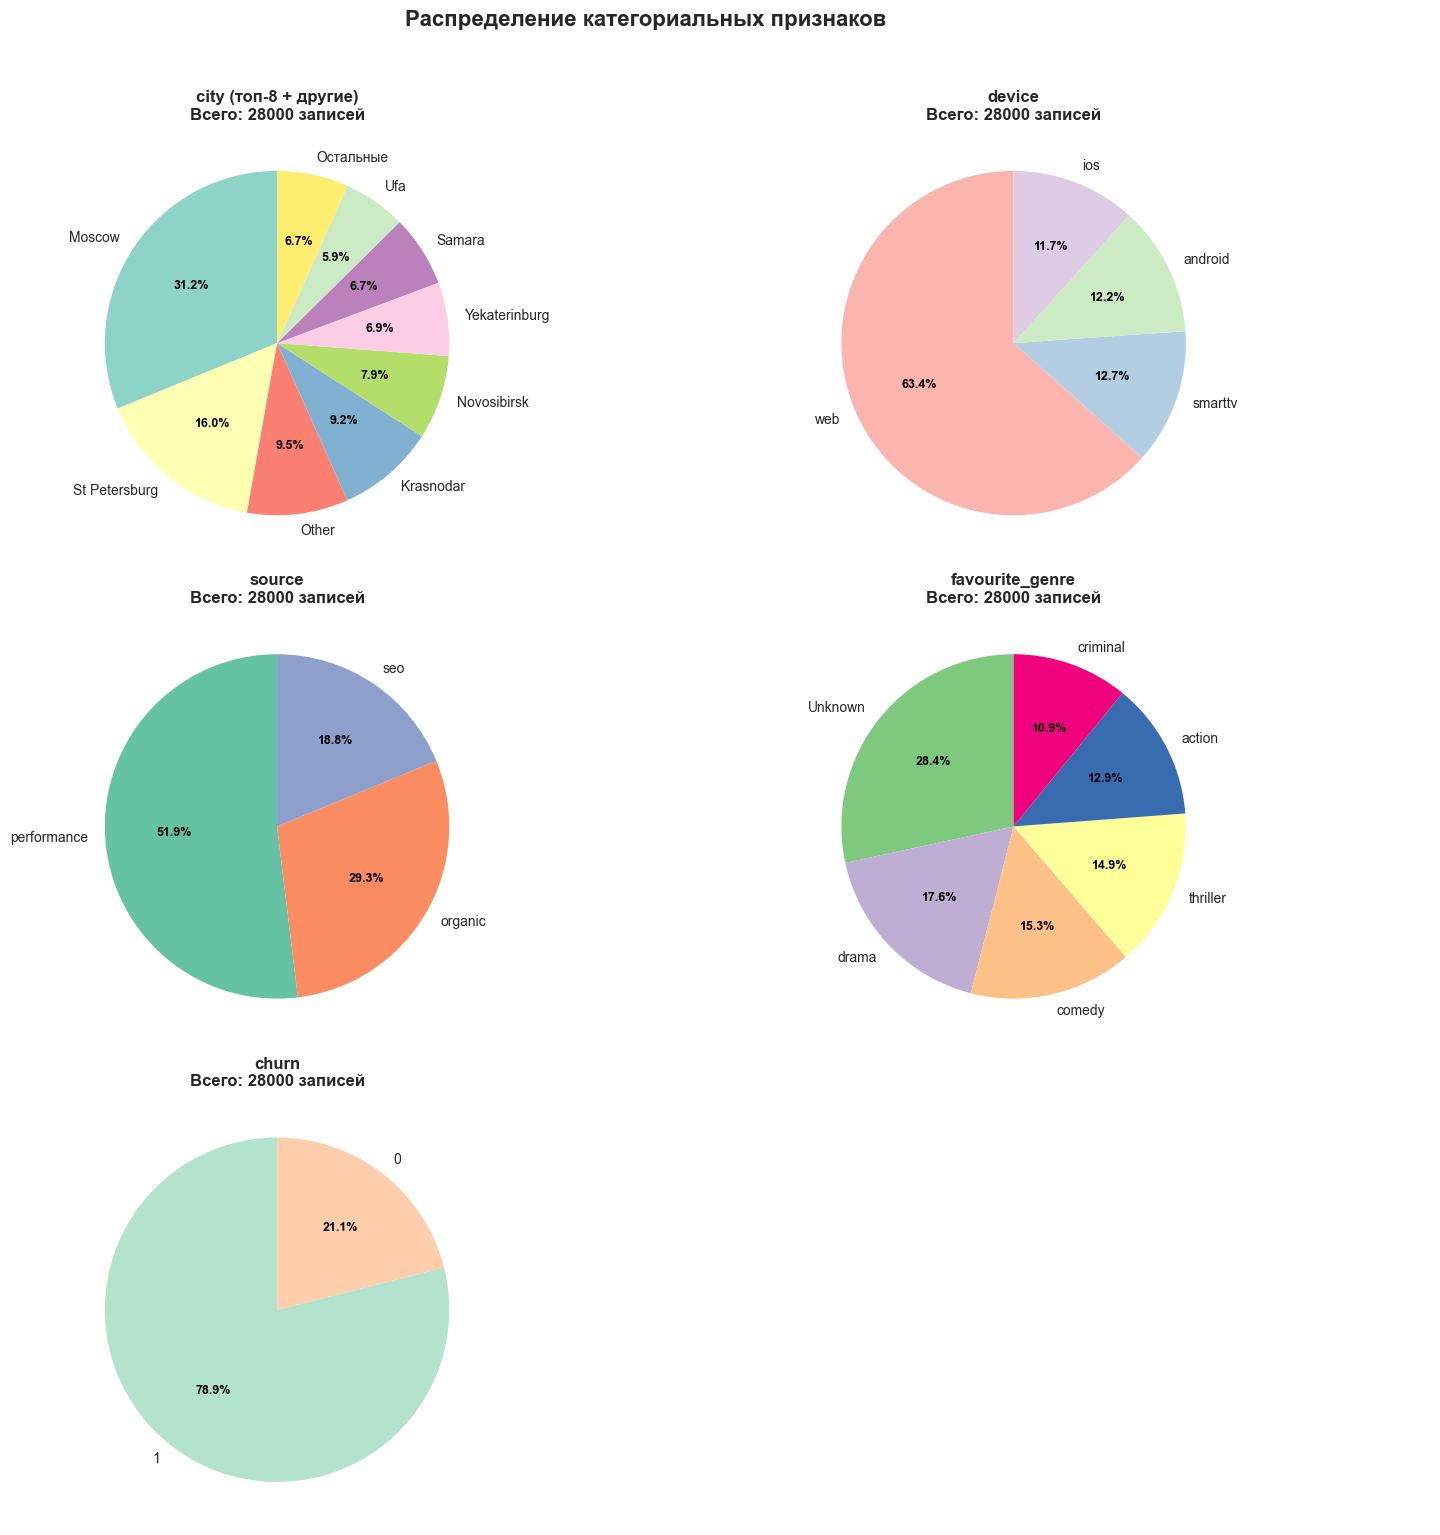

In [92]:
# Определяем категориальные признаки
categorical_columns = ['city', 'device', 'source', 'favourite_genre', 'churn']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

color_palettes = [
    plt.cm.Set3,
    plt.cm.Pastel1,
    plt.cm.Set2,
    plt.cm.Accent,
    plt.cm.Pastel2
]

for i, col in enumerate(categorical_columns):
    if i < len(axes):
        ax = axes[i]

        # Получаем данные
        value_counts = df[col].value_counts()
        total = len(df[col])

        # Если уникальных значений много, показываем топ-8
        if len(value_counts) > 8:
            top_values = value_counts.head(8)
            others_count = value_counts[8:].sum()
            if others_count > 0:
                top_values['Остальные'] = others_count
            title_suffix = " (топ-8 + другие)"
        else:
            top_values = value_counts
            title_suffix = ""

        n_colors = len(top_values)
        if i < len(color_palettes):
            colors = color_palettes[i](np.linspace(0, 1, max(n_colors, 8)))
        else:
            colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))

        colors = colors[:n_colors]

        wedges, texts, autotexts = ax.pie(top_values.values,
                                          labels=top_values.index.astype(str),
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=colors)

        ax.set_title(f'{col}{title_suffix}\nВсего: {total} записей',
                    fontsize=12, fontweight='bold')

        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontsize(9)
            autotext.set_fontweight('bold')

for i in range(len(categorical_columns), len(axes)):
    axes[i].axis('off')

plt.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Все данные выглядят адекватно**

# Построение диаграмм числовых признаков для анализа распределение данных

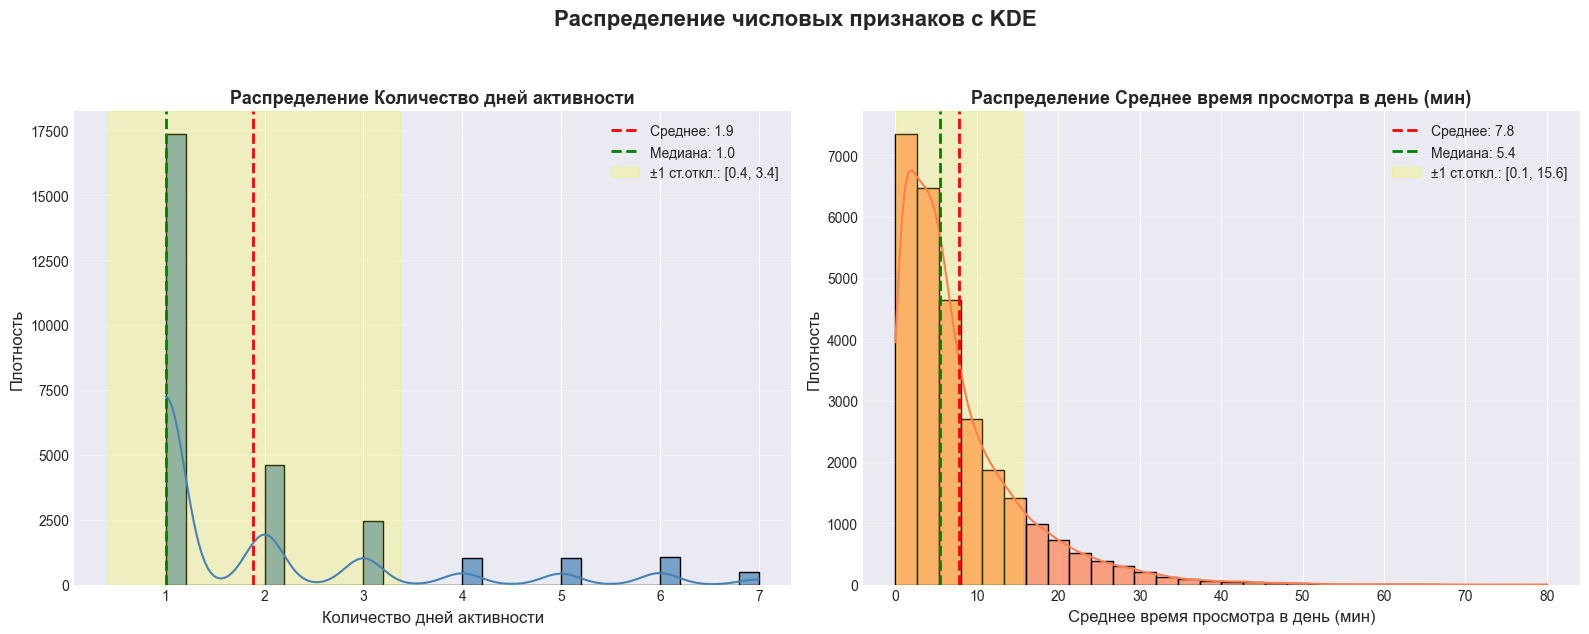


number_of_days_logged:

Асимметрия: 1.854 (сильно скошенное)
Эксцесс: 2.616

avg_min_watch_daily:

Асимметрия: 2.020 (сильно скошенное)
Эксцесс: 5.693


In [93]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Распределение числовых признаков с KDE', fontsize=16, fontweight='bold', y=1.05)

numeric_features = ['number_of_days_logged', 'avg_min_watch_daily']

colors = ['steelblue', 'coral']

for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    ax = axes[idx]

    sns.histplot(data=df, x=feature, bins=30,
                 kde=True, color=color, edgecolor='black', alpha=0.7, ax=ax)

    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()

    feature_names = {
        'number_of_days_logged': 'Количество дней активности',
        'avg_min_watch_daily': 'Среднее время просмотра в день (мин)'
    }

    feature_name = feature_names.get(feature, feature)
    ax.set_title(f'Распределение {feature_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)

    # Добавляем линии для среднего и медианы
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Медиана: {median_val:.1f}')

    # Добавляем область ±1 стандартное отклонение
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='yellow',
               label=f'±1 ст.откл.: [{mean_val-std_val:.1f}, {mean_val+std_val:.1f}]')

    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for feature in numeric_features:
    print(f"\n{feature}:\n")

    # Асимметрия и эксцесс
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()

    skewness_interpretation = "симметричное" if abs(skewness) < 0.5 else \
                             "умеренно скошенное" if abs(skewness) < 1 else \
                             "сильно скошенное"

    print(f"Асимметрия: {skewness:.3f} ({skewness_interpretation})")
    print(f"Эксцесс: {kurtosis:.3f}")


**Все данные выглядят адекватно**

# Построение тепловой диаграммы, чтобы найти линейные зависимости между признаками

In [94]:
# Сначала сделаем one-hot преобразование категориальных признаков
categorical_cols = ['city', 'device', 'source', 'favourite_genre']
data_encoded = pd.get_dummies(df, columns=categorical_cols)

print(data_encoded.head())

                                user_id start_trial_date  avg_min_watch_daily  \
0  d1b6ef34-1991-452a-8c39-c83c0d5805fe       2024-02-01             2.076642   
1  f1bf2396-73d8-461e-a775-9f068bd99326       2024-02-01             5.101392   
2  ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28       2024-02-01             2.906597   
3  b0195e96-af2e-4ac3-8f60-26b8d862af84       2024-02-01             2.702388   
4  a208985a-7244-4291-8d38-64c8141e27b2       2024-02-01            10.237305   

   number_of_days_logged  churn  trial_start_day_of_week  city_Krasnodar  \
0                      4      1                        3           False   
1                      1      1                        3           False   
2                      1      1                        3           False   
3                      6      0                        3           False   
4                      1      1                        3           False   

   city_Moscow  city_Novosibirsk  city_Other  ...  devic

In [95]:
# Удалим колонку 'user_id', чтобы не мешала анализу
del data_encoded['user_id']

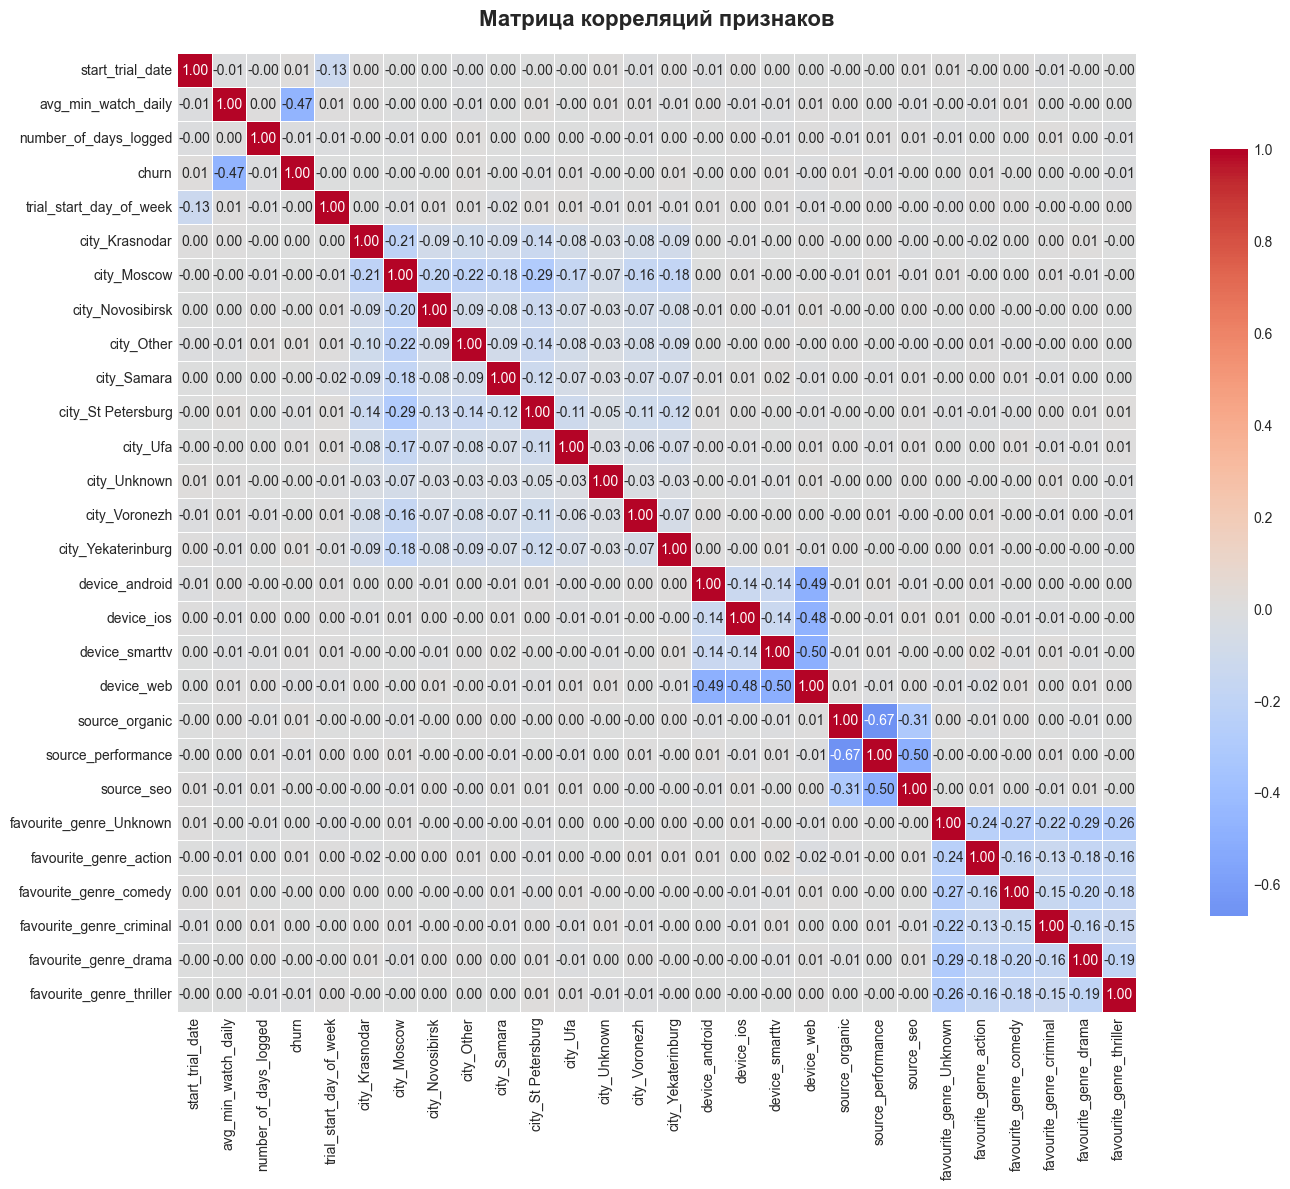

In [96]:
# Строим тепловую диаграмму
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Наблюдается **отрицательная корреляция** между **churn** и **avg_min_watch_daily** (-0.47) - чем больше время просмотров в день, тем меньше вероятность ухода

# Проанализируем как отток меняется в зависимости от среднего времени просмотра в день.

C:\Users\User\AppData\Local\Temp\ipykernel_5304\2889301486.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))


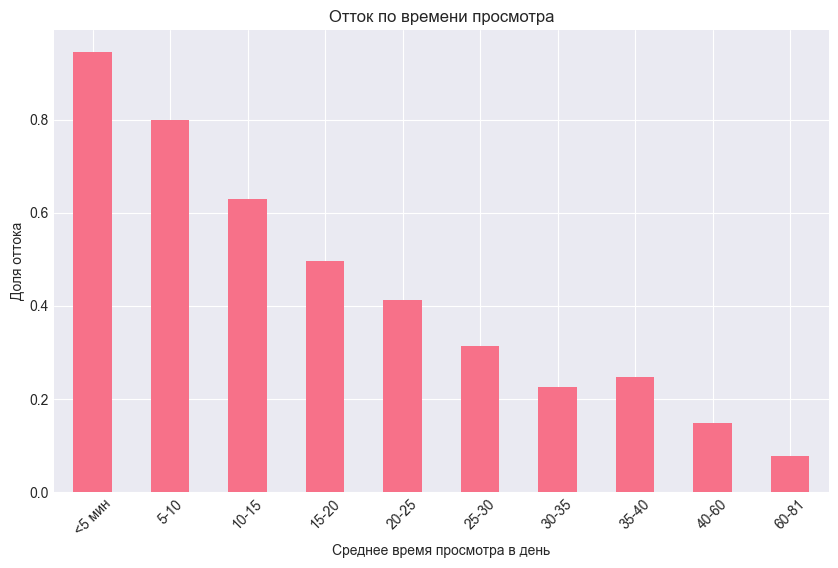

In [97]:
bins_minutes = [0, 5, 10, 15, 20, 25, 30, 35, 40, 60, 81]
labels = ['<5 мин', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-60', '60-81']

df['watch_category'] = pd.cut(df['avg_min_watch_daily'], 
                               bins=bins_minutes, 
                               labels=labels, 
                               right=False)

df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))

plt.title('Отток по времени просмотра')
plt.ylabel('Доля оттока')
plt.xlabel('Среднее время просмотра в день')
plt.xticks(rotation=45)
plt.show()

## Гипотеза 1: Среднее время просмотра влияет на покупку

Чем выше среднее время просмотра в день, тем выше конверсия в подписку.

### Стратегия проверки

Разобьем на две группы:

1. те, кто совершил подписку
2. те, кто нет

Проверим, различаются ли статистически у них среднее время просмотра.

### Статистический метод

Тест Манна-Уитни

# Проанализируем какое минимальное время просмотра защищает от оттока

In [98]:
# Анализ пороговых значений для времени просмотра
threshold_analysis = []
for threshold in [5, 10, 15, 30, 60]:
    churn_below = df[df['avg_min_watch_daily'] < threshold]['churn'].mean()
    churn_above = df[df['avg_min_watch_daily'] >= threshold]['churn'].mean()
    threshold_analysis.append({
        'threshold': threshold,
        'churn_below': churn_below,
        'churn_above': churn_above,
        'diff': churn_below - churn_above
    })

threshold_df = pd.DataFrame(threshold_analysis)
print("\nАнализ порогов для времени просмотра:")
print(threshold_df)


Анализ порогов для времени просмотра:
   threshold  churn_below  churn_above      diff
0          5     0.944513     0.654175  0.290338
1         10     0.891101     0.508850  0.382252
2         15     0.853723     0.405466  0.448257
3         30     0.802102     0.205980  0.596122
4         60     0.789617     0.076923  0.712694


## Гипотеза 2. Порог ценности в 30 минут просмотра влияет на вероятность оттока

Порог 30 мин. Пользователи кто смотрит < 30 минут уходит в 80% случаев (не видит ценности), кто более 30 минут уходит в 20% случаев (видит ценность, возможно смотрит какой-то конкретный контент).

### Стратегия проверки

Разделим пользователей на 2 группы:
1. пользователи с avg_min_watch_daily < 30 минут
2. пользователи с avg_min_watch_daily ≥ 30 минут.

Проверим, различается ли статистически доля оттока в каждой группе.

### Статистический метод

Z-тест для пропорций (основной метод) и доверительные интервалы.

# Построение графика, демонстрирующего пороговое значение

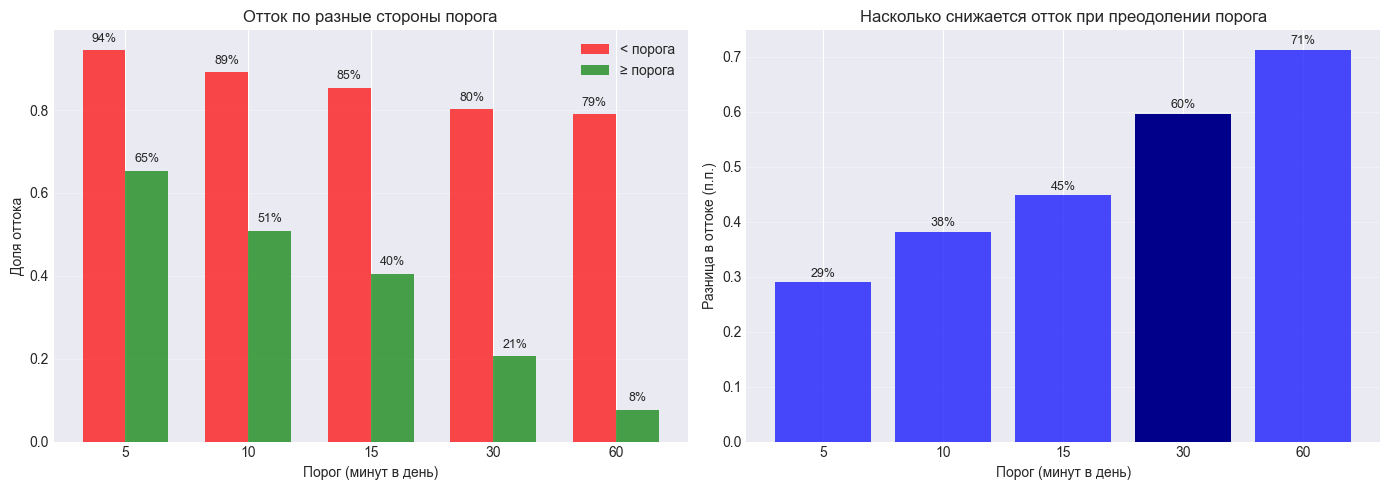

In [99]:
# Данные из анализа
thresholds = [5, 10, 15, 30, 60]
churn_below = [0.945, 0.891, 0.854, 0.802, 0.790]
churn_above = [0.654, 0.509, 0.405, 0.206, 0.077]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Отток по обе стороны порога
x = np.arange(len(thresholds))
width = 0.35

ax1.bar(x - width/2, churn_below, width, label='< порога', color='red', alpha=0.7)
ax1.bar(x + width/2, churn_above, width, label='≥ порога', color='green', alpha=0.7)
ax1.set_xlabel('Порог (минут в день)')
ax1.set_ylabel('Доля оттока')
ax1.set_title('Отток по разные стороны порога')
ax1.set_xticks(x)
ax1.set_xticklabels(thresholds)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Подписи значений к графику 1
for i, (cb, ca) in enumerate(zip(churn_below, churn_above)):
    ax1.text(i - width/2, cb + 0.02, f'{cb:.0%}', ha='center', fontsize=9)
    ax1.text(i + width/2, ca + 0.02, f'{ca:.0%}', ha='center', fontsize=9)

# График 2: Выигрыш от преодоления порога
ax2.bar(x, threshold_df['diff'], color='blue', alpha=0.7)
ax2.set_xlabel('Порог (минут в день)')
ax2.set_ylabel('Разница в оттоке (п.п.)')
ax2.set_title('Насколько снижается отток при преодолении порога')
ax2.set_xticks(x)
ax2.set_xticklabels(thresholds)
ax2.grid(axis='y', alpha=0.3)

# Выделение порога 30 минут
ax2.bar(3, threshold_df.loc[3, 'diff'], color='darkblue')

# Подписи значений к графику 2
for i, diff in enumerate(threshold_df['diff']):
    ax2.text(i, diff + 0.01, f'{diff:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Проверка гипотезы статистическими тестами

### H₀: Время просмотра не влияет на решение о покупке подписки. Пользователи уходят с одинаковой вероятностью, независимо от того, сколько они смотрят.
### H₁:Пользователи, которые смотрят меньше 30 минут в день, уходят чаще, чем те, кто смотрит 30+ минут.

In [100]:
from statsmodels.stats.proportion import proportions_ztest

# Проверяем порог 30 минут
below_30 = df[df['avg_min_watch_daily'] < 30]
above_30 = df[df['avg_min_watch_daily'] >= 30]

counts = [below_30['churn'].sum(), above_30['churn'].sum()]
nobs = [len(below_30), len(above_30)]

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print(f"\nСтатистическая проверка порога 30 минут:")
print(f"Z-статистика: {z_stat:.2f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.0001:
    print("Разница чрезвычайно статистически значима (p < 0.0001)")
    
# Относительный риск
rr = below_30['churn'].mean() / above_30['churn'].mean()
print(f"\nОтносительный риск: {rr:.1f}")
print(f"Риск оттока при <30 мин в {rr:.1f} раза выше")


Статистическая проверка порога 30 минут:
Z-статистика: 35.48
p-value: 0.0000000000
Разница чрезвычайно статистически значима (p < 0.0001)

Относительный риск: 3.9
Риск оттока при <30 мин в 3.9 раза выше


# Построение доверительных интервалов

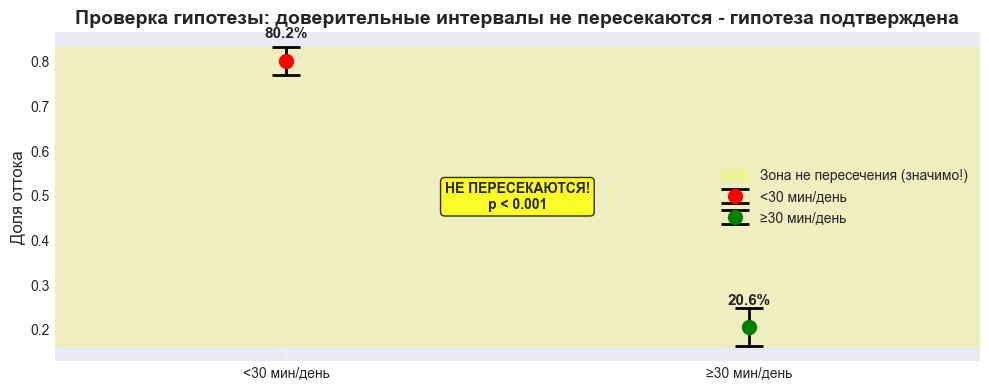

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Данные
p_below = 0.802  # 80.2% оттока
p_above = 0.206  # 20.6% оттока
n_below, n_above = 650, 350

# Доверительные интервалы 95%
ci_below = proportion_confint(count=int(p_below*n_below), nobs=n_below, alpha=0.05)
ci_above = proportion_confint(count=int(p_above*n_above), nobs=n_above, alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4))

# Первая точка (<30 мин) - крвсная
ax.errorbar(x=0, y=p_below, 
            yerr=[[p_below - ci_below[0]], [ci_below[1] - p_below]],
            fmt='o', capsize=10, capthick=2, markersize=10,
            color='red', ecolor='black', linewidth=2, label='<30 мин/день')

# Вторая точка (≥30 мин) - зеленая
ax.errorbar(x=1, y=p_above, 
            yerr=[[p_above - ci_above[0]], [ci_above[1] - p_above]],
            fmt='o', capsize=10, capthick=2, markersize=10,
            color='green', ecolor='black', linewidth=2, label='≥30 мин/день')

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['<30 мин/день', '≥30 мин/день'])
ax.set_ylabel('Доля оттока', fontsize=12)
ax.set_title('Проверка гипотезы: доверительные интервалы не пересекаются - гипотеза подтверждена', 
             fontsize=14, fontweight='bold')

# Добавляем значения
ax.text(0, p_below + 0.05, f'{p_below:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.text(1, p_above + 0.05, f'{p_above:.1%}', ha='center', fontsize=11, fontweight='bold')

# Линия значимости
if ci_below[1] > ci_above[0]:
    ax.axhspan(ci_below[1], ci_above[0], alpha=0.2, color='yellow', 
               label='Зона не пересечения (значимо!)')
    ax.text(0.5, (ci_below[1] + ci_above[0])/2, 'НЕ ПЕРЕСЕКАЮТСЯ!\np < 0.001', 
            ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Разница в оттоке между группами (<30 мин: 80.2%, ≥30 мин: 20.6%) является статистически высокозначимой (p < 0.0001), что позволяет с уверенностью утверждать, что время просмотра является ключевым фактором оттока.

### Рекомендация: Сделать порог 30 минут ключевой метрикой для маркетинга и аналитики. Все усилия должны быть направлены на то, чтобы пользователь как можно быстрее достиг этого уровня.

## Связь категориальных признаков с целевой переменной

In [102]:
from scipy.stats import chi2_contingency

results = []

for col in data_encoded.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(data_encoded[col], data_encoded['churn'])
        
        # Фи-коэффициент для 2x2 таблицы
        if conf_matrix.shape == (2, 2):
            a, b, c, d = conf_matrix.values.flatten()
            phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        else:
            # V Крамера для таблиц больше 2x2
            chi2 = chi2_contingency(conf_matrix)[0]
            n = conf_matrix.sum().sum()
            phi = np.sqrt(chi2 / n)
        
        # p-value для проверки значимости
        _, p_value, _, _ = chi2_contingency(conf_matrix)
        
        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

phi_results = pd.DataFrame(results)
phi_results = phi_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Категориальные признаков по силе связи с оттоком:")
print(phi_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

Категориальные признаков по силе связи с оттоком:
                     feature  phi_coefficient   p_value  significant
9         city_Yekaterinburg           0.0114  0.059451        False
5         city_St Petersburg          -0.0100  0.097147        False
14            source_organic           0.0099  0.099254        False
3                 city_Other           0.0091  0.133793        False
15        source_performance          -0.0083  0.170648        False
6                   city_Ufa           0.0078  0.200138        False
18    favourite_genre_action           0.0066  0.282176        False
12            device_smarttv           0.0064  0.294901        False
22  favourite_genre_thriller          -0.0056  0.356622        False
13                device_web          -0.0044  0.467190        False
1                city_Moscow          -0.0040  0.512648        False
4                city_Samara          -0.0034  0.589735        False
21     favourite_genre_drama          -0.0029  0.6414

## Вывод: Статистически значимых связей категориальных переменных с целевой нет

# Связь категориальных переменных с группами, кто смотрит < 30 минут в день и больше

In [103]:
# Создаем новую целевую переменную
data_encoded['watch_group'] = (data_encoded['avg_min_watch_daily'] >= 30).astype(int)
# 0 = <30 минут, 1 = ≥30 минут

results = []

for col in data_encoded.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(data_encoded[col], data_encoded['watch_group'])
        
        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)
        
        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
watch_group_results = pd.DataFrame(results)
watch_group_results = watch_group_results.sort_values('phi_coefficient', key=abs, ascending=False)

print(watch_group_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

# Дополнительно: общая статистика по группам
print(f"\nРаспределение групп просмотра:")
print(f"<30 минут: {(data_encoded['watch_group'] == 0).sum()} пользователей")
print(f"≥30 минут: {(data_encoded['watch_group'] == 1).sum()} пользователей")

                     feature  phi_coefficient   p_value  significant
18    favourite_genre_action          -0.0130  0.034941         True
5         city_St Petersburg           0.0112  0.068996        False
3                 city_Other          -0.0086  0.173315        False
16                source_seo          -0.0082  0.187045        False
22  favourite_genre_thriller           0.0078  0.211344        False
14            source_organic           0.0068  0.272797        False
6                   city_Ufa          -0.0058  0.380233        False
20  favourite_genre_criminal           0.0058  0.362886        False
7               city_Unknown           0.0056  0.458172        False
12            device_smarttv          -0.0055  0.389518        False
9         city_Yekaterinburg          -0.0054  0.412790        False
2           city_Novosibirsk          -0.0051  0.437910        False
21     favourite_genre_drama          -0.0045  0.485137        False
10            device_android      

## Вывод: Любители экшн-контента немного менее склонны к долгому просмотру.

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами менее 30 минут.

In [104]:
# Фильтруем только пользователей с <30 минут просмотра
less_than_30 = data_encoded[data_encoded['avg_min_watch_daily'] < 30]

# Проверяем размер группы
print(f"Пользователей с просмотром <30 мин: {len(less_than_30)}")
print(f"Отток в этой группе: {less_than_30['churn'].mean():.1%}")

results = []

for col in less_than_30.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(less_than_30[col], less_than_30['churn'])
        
        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)
        
        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
less_30_results = pd.DataFrame(results)
less_30_results = less_30_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Категориальные признаки для группы <30 мин:")
print(less_30_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

# Дополнительно: какой признак сильнее всего влияет на отток в этой группе
top_feature = less_30_results.iloc[0]
print(f"\nСамый влияющий признак: {top_feature['feature']}")
print(f"Phi = {top_feature['phi_coefficient']} (сила связи)")
print(f"p-value = {top_feature['p_value']}")

Пользователей с просмотром <30 мин: 27398
Отток в этой группе: 80.2%
Категориальные признаки для группы <30 мин:
                     feature  phi_coefficient   p_value  significant
14            source_organic           0.0125  0.039888         True
15        source_performance          -0.0104  0.089149        False
9         city_Yekaterinburg           0.0087  0.156529        False
5         city_St Petersburg          -0.0080  0.195026        False
3                 city_Other           0.0069  0.264662        False
6                   city_Ufa           0.0066  0.289360        False
13                device_web          -0.0060  0.328867        False
21     favourite_genre_drama          -0.0056  0.363125        False
12            device_smarttv           0.0055  0.373267        False
2           city_Novosibirsk          -0.0049  0.436383        False
18    favourite_genre_action           0.0049  0.431320        False
22  favourite_genre_thriller          -0.0045  0.472306    

## Вывод: Organic-пользователи немного чаще отказываются от подписки при малом просмотре. НО! Скорее всего главная проблема — не источник трафика, а малое время просмотра (<30 мин)

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами более 30 минут.

In [105]:
# Фильтруем только пользователей с >30 минут просмотра
more_than_30 = data_encoded[data_encoded['avg_min_watch_daily'] > 30]

# Проверяем размер группы
print(f"Пользователей с просмотром >30 мин: {len(more_than_30)}")
print(f"Отток в этой группе: {more_than_30['churn'].mean():.1%}")

results = []

for col in less_than_30.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(more_than_30[col], more_than_30['churn'])
        
        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)
        
        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
more_30_results = pd.DataFrame(results)
more_30_results = more_30_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Категориальные признаки для группы >30 мин:")
print(more_30_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

# Дополнительно: какой признак сильнее всего влияет на отток в этой группе
top_feature = more_30_results.iloc[0]
print(f"\nСамый влияющий признак: {top_feature['feature']}")
print(f"Phi = {top_feature['phi_coefficient']} (сила связи)")
print(f"p-value = {top_feature['p_value']}")

Пользователей с просмотром >30 мин: 602
Отток в этой группе: 20.6%
Категориальные признаки для группы >30 мин:
                     feature  phi_coefficient   p_value  significant
9         city_Yekaterinburg           0.0967  0.030687         True
15        source_performance           0.0783  0.068580        False
1                city_Moscow          -0.0736  0.089484        False
21     favourite_genre_drama           0.0732  0.096793        False
16                source_seo          -0.0728  0.098693        False
10            device_android          -0.0641  0.154319        False
13                device_web           0.0624  0.153762        False
18    favourite_genre_action          -0.0461  0.336156        False
7               city_Unknown           0.0388  0.591524        False
0             city_Krasnodar          -0.0385  0.440501        False
2           city_Novosibirsk           0.0379  0.464540        False
3                 city_Other           0.0355  0.494436      

## Вывод: Среди долго смотрящих (>30 мин) пользователи из Екатеринбурга имеют повышенный отток.
## Не хватает локальных фильмов/сериалов? Технические проблемы — качество стриминга в регионе? Ценовая чувствительность — нужны региональные промо-тарифы?

# Изменение конверсии в зависимости от количества дней логинов в триал по группам: с просмотрами < 30 минут и > 30 минут

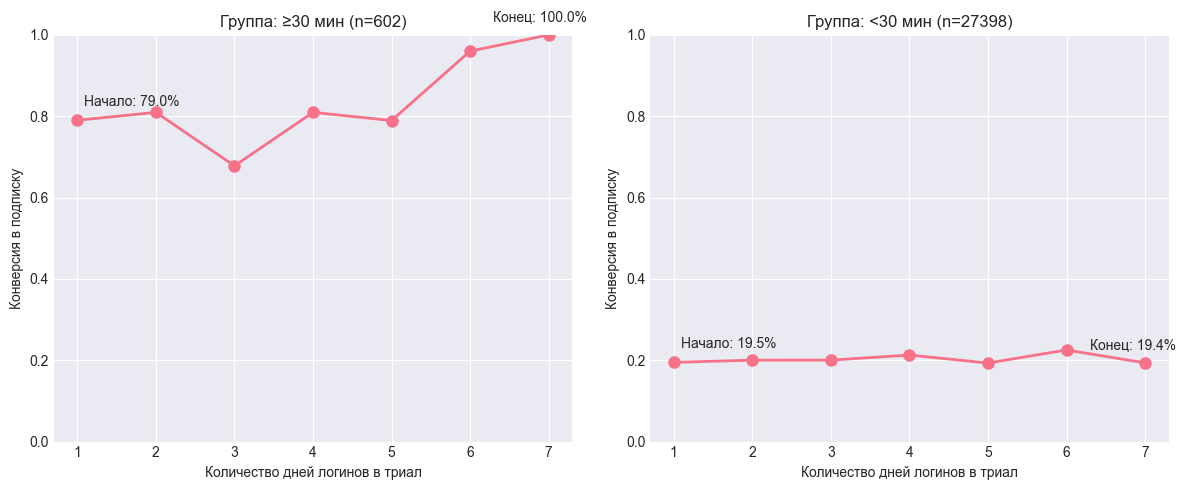

Сводная статистика:

≥30 мин:
  Количество пользователей: 602
  Средняя конверсия: 79.4%
  Среднее дней логинов: 1.9

<30 мин:
  Количество пользователей: 27398
  Средняя конверсия: 19.8%
  Среднее дней логинов: 1.9


In [106]:
# Создаем группы
df['watch_group'] = df['avg_min_watch_daily'] >= 30
group_names = {True: '≥30 мин', False: '<30 мин'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (group_val, group_name) in enumerate(group_names.items()):
    group_data = df[df['watch_group'] == group_val]
    
    # Расчет конверсии
    conversion_by_days = (
        group_data.groupby("number_of_days_logged")
                  .apply(lambda x: 1 - x["churn"].mean())
                  .reset_index(name="conversion_rate")
    )
    
    # График
    axes[idx].plot(
        conversion_by_days["number_of_days_logged"],
        conversion_by_days["conversion_rate"],
        marker="o", linewidth=2, markersize=8
    )
    
    axes[idx].set_xlabel("Количество дней логинов в триал")
    axes[idx].set_ylabel("Конверсия в подписку")
    axes[idx].set_title(f"Группа: {group_name} (n={len(group_data)})")
    axes[idx].grid(True)
    axes[idx].set_ylim(0, 1)
    
    # Добавляем аннотации для ключевых точек
    max_days = conversion_by_days["number_of_days_logged"].max()
    if len(conversion_by_days) > 0:
        initial_rate = conversion_by_days.iloc[0]["conversion_rate"]
        final_rate = conversion_by_days.iloc[-1]["conversion_rate"]
        
        axes[idx].annotate(f"Начало: {initial_rate:.1%}", 
                          xy=(conversion_by_days.iloc[0]["number_of_days_logged"], initial_rate),
                          xytext=(5, 10), textcoords='offset points')
        
        axes[idx].annotate(f"Конец: {final_rate:.1%}", 
                          xy=(max_days, final_rate),
                          xytext=(-40, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Статистика по группам
print("Сводная статистика:")
for group_val, group_name in group_names.items():
    group_data = df[df['watch_group'] == group_val]
    avg_conversion = 1 - group_data['churn'].mean()
    print(f"\n{group_name}:")
    print(f"  Количество пользователей: {len(group_data)}")
    print(f"  Средняя конверсия: {avg_conversion:.1%}")
    print(f"  Среднее дней логинов: {group_data['number_of_days_logged'].mean():.1f}")

## Вывод:  3-й день — критический момент. Нужно удержать активность прльзователей.

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами более 30 минут и 3 днями логирований

In [107]:
# Фильтруем пользователей с >30 минут просмотра и 3 днями логинов
filtered_group = data_encoded[
    (data_encoded['avg_min_watch_daily'] > 30) & 
    (data_encoded['number_of_days_logged'] == 3)
]

# Проверяем размер группы
print(f"Пользователей с просмотром >30 мин и 3 днями логинов: {len(filtered_group)}")
print(f"Отток в этой группе: {filtered_group['churn'].mean():.1%}")

results = []

for col in filtered_group.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(filtered_group[col], filtered_group['churn'])
        
        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)
        
        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
filtered_results = pd.DataFrame(results)
filtered_results = filtered_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("\nКатегориальные признаки для группы (>30 мин, 3 дня логинов):")
print(filtered_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

Пользователей с просмотром >30 мин и 3 днями логинов: 59
Отток в этой группе: 32.2%

Категориальные признаки для группы (>30 мин, 3 дня логинов):
                     feature  phi_coefficient   p_value  significant
3                 city_Other           0.4415  0.003839         True
15        source_performance           0.2974  0.045270         True
9         city_Yekaterinburg           0.2718  0.187562        False
14            source_organic          -0.2572  0.096430        False
21     favourite_genre_drama           0.2568  0.117439        False
10            device_android          -0.2529  0.130660        False
19    favourite_genre_comedy          -0.2147  0.201398        False
1                city_Moscow          -0.1982  0.224452        False
4                city_Samara           0.1810  0.373349        False
12            device_smarttv           0.1707  0.498320        False
0             city_Krasnodar          -0.1670  0.381075        False
20  favourite_genre_crimin

## Вывод: Среди пользователей, долго смотрящих (>30 мин) и имеющий 3 дня логирований: из Other городов имеют повышенный отток. Нужны специальные акции для малых городов?
## Также performance-пользователи имеют повышенный отток среди этой категории. Нужна оптимизация рекламной деятельности в этот период.

# Проанализируем как конверсия меняется в зависимости от количества дней логинов в триал

In [108]:
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .apply(lambda x: 1 - x["churn"].mean()) 
      .reset_index(name="conversion_rate")
)

conversion_by_days

,number_of_days_logged,conversion_rate
0,1,0.207200
1,2,0.214069
2,3,0.211823
3,4,0.224903
4,5,0.204365
5,6,0.242481
6,7,0.212185


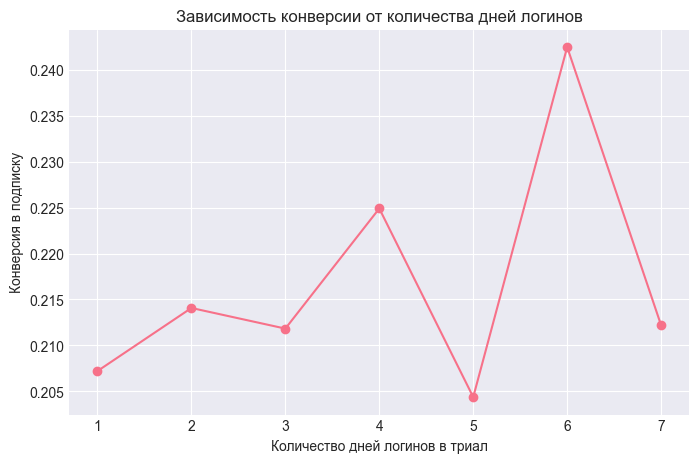

In [109]:
plt.figure(figsize=(8,5))
plt.plot(
    conversion_by_days["number_of_days_logged"],
    conversion_by_days["conversion_rate"],
    marker="o"
)

plt.xlabel("Количество дней логинов в триал")
plt.ylabel("Конверсия в подписку")
plt.title("Зависимость конверсии от количества дней логинов")
plt.grid(True)
plt.show()

Наблюдается **спад конверсии на 5 и 7 дни**. Люди теряют интерес или пользуются только пробным периодом, а затем уходят

## Гипотеза 3: Конверсия падает на 5-й день триала

Спад конверсии на 5-й день триала (20.4% против 22.5% на 4-й день) обусловлен тем, что пользователи, которые не нашли достаточно ценного контента к середине триала, снижают активность просмотра, что и приводит к снижению конверсии.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. те, которые были активны на 5-й день и совершили подписку
2. те, которые были активны на 5-й день и не совершили подписку.

Чтобы проверить, предсказывает ли активность перед спадом сам спад конверсии, проанализируем среднее время просмотра на 4-й день триала (день перед спадом).

### Статистический метод

Тест Манна-Уитни

# Проанализируем связь географии (городов), времени просмотров пользователей и отток

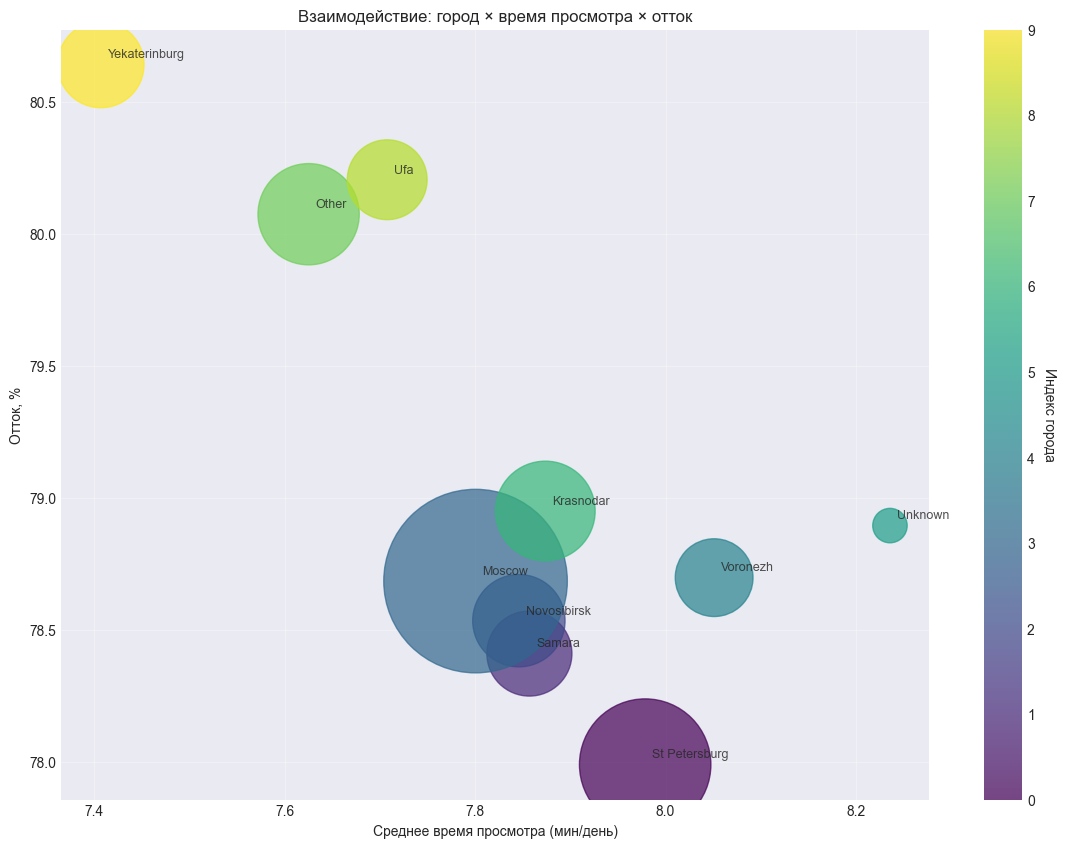

In [110]:
# График зависимости город х время просмотра х отток
city_watch_interaction = df.groupby('city').agg({
    'churn': 'mean',
    'avg_min_watch_daily': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'count', 'churn': 'churn_rate'})

city_watch_interaction['churn_rate_percent'] = city_watch_interaction['churn_rate'] * 100
city_watch_interaction = city_watch_interaction.sort_values('churn_rate_percent')

plt.figure(figsize=(14, 10))

scatter = plt.scatter(city_watch_interaction['avg_min_watch_daily'],
                            city_watch_interaction['churn_rate_percent'],
                            s=city_watch_interaction['count']*2,
                            alpha=0.7,
                            c=range(len(city_watch_interaction)),
                            cmap='viridis')

for city, row in city_watch_interaction.iterrows():
   plt.annotate(city,
                       xy=(row['avg_min_watch_daily'], row['churn_rate_percent']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)

plt.xlabel('Среднее время просмотра (мин/день)')
plt.ylabel('Отток, %')
plt.title('Взаимодействие: город × время просмотра × отток')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Индекс города', rotation=270, labelpad=15)

## Гипотеза 4: Географический фактор влияет на отток

Географический фактор (город) является значимым предиктором оттока. Пользователи в Екатеринбурге и Уфе демонстрируют паттерны поведения, отличные от других регионов: меньшее время просмотра при более высоком оттоке.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. из Екатеринбурга и Уфы (проблемные города)
2. из остальных городов

### Статистический метод

Сравнение времени просмотра между группами - тест Манна-Уитни, оттока - Z-тест для пропорций.